In [11]:
import matplotlib.pyplot as plt
import awkward as ak
import numpy as np

from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea.analysis_tools import PackedSelection

import dask_awkward as dak

import itertools as iter

import hist
from hist import Hist

import vector as vec

import numba

In [12]:
class ScoutingNanoAODSchema(NanoAODSchema):

    mixins = {
        **NanoAODSchema.mixins,
        "ScoutingJet": "Jet" 
    }
    

In [150]:
def mass_asymmetry(sj, tj):
    total_p4 = sj[:,0] + sj[:,1] + sj[:,2] + sj[:,3] + sj[:,4] + sj[:,5]
    cart = ak.cartesian([total_p4, tj])
    vector = (cart['1'].j1 + cart['1'].j2 + cart['1'].j3)
    other_vector = (cart['0'] - vector)

    vm = vector.mass
    ovm =other_vector.mass
    masym = (vm - ovm)/(vm + ovm)
    return masym

def tri_mds(tj):
    den=((tj.j1+tj.j2+tj.j3).mass**2)+(tj.j1.mass**2)+(tj.j2.mass**2)+(tj.j3.mass**2)

    m12=((tj.j1+tj.j2).mass**2)/den
    m13=((tj.j1+tj.j3).mass**2)/den
    m23=((tj.j2+tj.j3).mass**2)/den
    #d=ak.zip({"1":m12, "2":m13,"3":m23})
    #d=ak.concatenate([m12[:, np.newaxis], m13[:, np.newaxis],m23[:, np.newaxis]],axis=1)

    r13 = 1/(3**0.5)
    mds=((m12**0.5)-r13)**2 + ((m13**0.5)-r13)**2 + ((m23**0.5)-r13)**2
    #tmds = mds,d[0],d[1],d[2]
    # print(tmds)
    # print(len(tmds))
    return mds, m12, m13, m23

In [14]:
file_list = [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0000.txt").readlines()] + [line.strip('\n') for line in open("TTto4Q_TuneCP5_13p6TeV_powheg-pythia8_0001.txt").readlines()]
file_list = ["root://cmseos.fnal.gov//" + string for string in file_list]

NanoAODSchema.warn_missing_crossrefs = False

events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

small_events = NanoEventsFactory.from_root(
    {file : "Events" for file in file_list[0:2]},
    schemaclass=ScoutingNanoAODSchema,
    metadata={"dataset": "TTto4Q_TuneCP5_13p6TeV_powheg-pythia8"},
).events()

#uproot.concatenate(file_list)

/uscms/home/jlawless/nobackup/miniforge3/lib/python3.10/site-packages/coffea/nanoevents/methods/candidate.py:11: FutureWarning: In version 2024.7.0 (target date: 2024-06-30 11:59:59-05:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


In [15]:
len(small_events.ScoutingJet.compute())

105144

In [16]:
scouting_selection = PackedSelection()

scouting_selection.add("SixJets", ak.num(small_events.ScoutingJet, axis=1) >5)

In [17]:
good_events = small_events[scouting_selection.all("SixJets")]
selected_jets = good_events.ScoutingJet[:,0:6]
trijet = ak.combinations(selected_jets, 3, fields=["j1","j2","j3"])

In [174]:
vec.register_awkward()

mds_val, m12, m13, m23 = tri_mds(trijet)

good_events["Trijet"] = ak.zip(
    {
        "j1": trijet.j1,
        "j2": trijet.j2,
        "j3": trijet.j3,
        "px": trijet.j1.px + trijet.j2.px + trijet.j3.px, 
        "py": trijet.j1.py + trijet.j2.py + trijet.j3.py, 
        "pz": trijet.j1.pz + trijet.j2.pz + trijet.j3.pz,
        "e": trijet.j1.E + trijet.j2.E + trijet.j3.E,
        "masym": mass_asymmetry(selected_jets,trijet),
        "mds": mds_val,
        "m12": m12,
        "m13": m13,
        "m23": m23
    },
    with_name="Momentum4D"
)

good_events["HT"] = ak.sum(abs(good_events.ScoutingJet.pt), axis=1)

In [175]:
h1 = Hist(
    hist.axis.Regular(50, 0, 3000, name="x", label="HT"),
    hist.storage.Weight()
)
h1.fill(good_events.HT.compute())

Hist(Regular(50, 0, 3000, name='x', label='HT'), storage=Weight()) # Sum: WeightedSum(value=90743, variance=90743) (WeightedSum(value=90748, variance=90748) with flow)

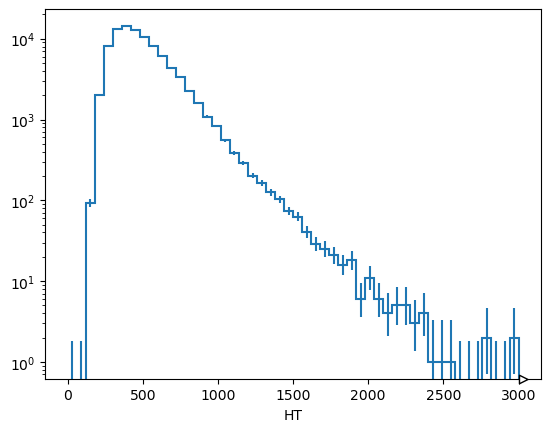

In [176]:
h1.plot()
plt.yscale("log")

In [169]:
h2 = Hist(
    hist.axis.Regular(50, 0, 3600, name="x", label="Jet Pt"),
    hist.storage.Weight()
)
h2.fill(ak.flatten(good_events.ScoutingJet.pt).compute())

Hist(Regular(50, 0, 3600, name='x', label='Jet Pt'), storage=Weight()) # Sum: WeightedSum(value=930810, variance=930810)

In [158]:
good_events.Trijet.fields

['j1', 'j2', 'j3', 'px', 'py', 'pz', 'e', 'masym', 'mds', 'm12', 'm13', 'm23']

In [31]:
h3 = Hist(
    hist.axis.Regular(50, 0, 1, name="x", label="mds"),
    hist.storage.Weight()
)
h3.fill(ak.flatten(good_events.Trijet.mds.compute()))

Hist(Regular(50, 0, 1, name='x', label='mds'), storage=Weight()) # Sum: WeightedSum(value=1.81496e+06, variance=1.81496e+06)

In [39]:
h4 = Hist(
    hist.axis.Regular(50, 100, 300, name="x", label="Trijet Invariant Mass"),
    hist.axis.StrCategory(['Full', 'Cut'], growth=True, name='dataset'),
    hist.storage.Weight()
)
h4.fill(ak.flatten(good_events.Trijet.m.compute()), "Full")
cut = (good_events.Trijet.masym < 0.15) and (good_events.Trijet.mds < 0.175)
h4.fill(ak.flatten(good_events.Trijet[cut].m.compute()), "Cut")

TypeError: Cannot determine length of collection with unknown partition sizes without executing the graph.
Use `dask_awkward.num(..., axis=0)` if you want a lazy Scalar of the length.
If you want to eagerly compute the partition sizes to have the ability to call `len` on the collection, use `.eager_compute_divisions()` on the collection.

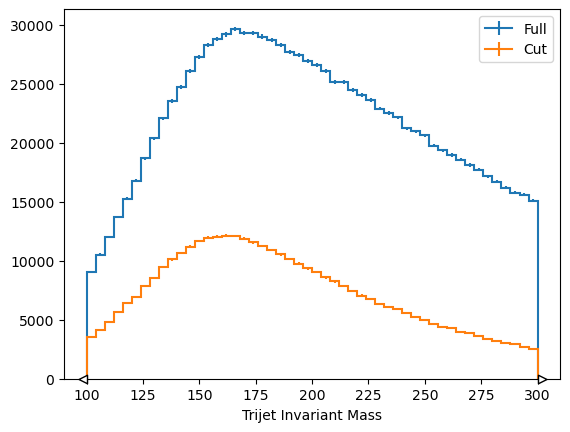

In [37]:
h1.plot(stack=False, histtype="step")
plt.legend()

In [31]:
a1 = ak.Array(np.arange(10))
a2 = ak.Array(np.arange(10,20))
ak.zip(arrays=[a1,a2])

<Array [(0, 10), (1, 11), ..., (8, ...), (9, 19)] type='10 * (int64, int64)'>